# Dolomite surface titration in NaCl — speciation, calculated pH, surface charge

After **Pokrovsky et al. (1999)**. No surface complexation model is fitted or assumed. The workflow is:

* the carbonate system is treated as an **open system** with a **fixed pCO₂**, so CO₂(aq), HCO₃⁻ and CO₃²⁻ follow from pCO₂ and pH,
* the free ion concentrations (H⁺, Ca²⁺, Mg²⁺, Na⁺, Cl⁻) are the unknowns of the **mass balances** for Ca, Mg, Na and Cl,
* the **pH of every solution is calculated**, not taken from the electrode, from the reactive-ion charge balance,
* the **surface charge is the proton mass balance** between the conservative A+B mixture and the reacted suspension C — i.e. the net protons the dolomite surface took up or released.

Everything below is derived from the measured cation concentrations and the aqueous speciation only.

## 1. Molar masses and unit conversion

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import brentq, fsolve

# molar masses (g/mol)
mmNa, mmCl, mmCa, mmMg = 22.990, 35.453, 40.078, 24.305

def ppm_to_M(ppm, mm):
    """mg/L divided by g/mol -> mol/L"""
    return ppm / 1000.0 / mm

## 2. Equilibrium constants at 25 °C (log₁₀ K)

Reactions are written as dissociations (complex on the left, basis species on the right);
the number is the log K of that dissociation.

In [2]:
# carbonate system -- open system, pCO2 fixed
logKH = -1.468     # CO2(g)  = CO2(aq)      : [CO2aq] = 10**logKH * pCO2
logK1 = -6.345     # CO2(aq) + H2O = H+ + HCO3-
logK2 = -10.329    # HCO3-         = H+ + CO3^2-
logKw = -13.995    # H2O           = H+ + OH-

# metal-ligand complexes  (log K of the dissociation as written)
logK = {
    'CaCl':   0.696,   # CaCl+     = Ca2+ + Cl-
    'CaCO3':  7.002,   # CaCO3(aq) = Ca2+ + HCO3- - H+
    'CaHCO3':-1.047,   # CaHCO3+   = Ca2+ + HCO3-
    'CaOH':  12.850,   # CaOH+     = Ca2+ + H2O - H+
    'MgCl':   0.135,   # MgCl+     = Mg2+ + Cl-
    'MgCO3':  7.350,   # MgCO3(aq) = Mg2+ + HCO3- - H+
    'MgHCO3':-1.036,   # MgHCO3+   = Mg2+ + HCO3-
    'MgOH':  11.785,   # MgOH+     = Mg2+ + H2O - H+
    'NaCO3':  9.815,   # NaCO3-    = Na+ + HCO3- - H+
    'NaHCO3':-0.154,   # NaHCO3(aq)= Na+ + HCO3-
    'NaCl':   0.777,   # NaCl(aq)  = Na+ + Cl-
    'NaOH':  14.180,   # NaOH(aq)  = Na+ + H2O - H+
}

## 3. Law of mass action for every species

Given the free ion concentrations `h, cCa, cMg, cNa, cCl` and a fixed `pCO2`,
each concentration follows from its K. The carbonate species are fixed by pCO₂ and pH
(open system). Water activity is taken as 1 (concentration basis; see the closing note).

In [3]:
def all_species(h, cCa, cMg, cNa, cCl, pCO2):
    # carbonate fixed by pCO2 and h  (open system)
    co2  = 10**logKH * pCO2
    hco3 = 10**logK1 * co2 / h        # CO2 + H2O = H+ + HCO3-
    co3  = 10**logK2 * hco3 / h       # HCO3-     = H+ + CO3^2-
    oh   = 10**logKw / h              # H2O       = H+ + OH-
    return {
        'H':   h,   'OH':  oh,  'CO2': co2, 'HCO3': hco3, 'CO3': co3,
        # calcium
        'Ca':     cCa,
        'CaCl':   cCa * cCl / 10**logK['CaCl'],
        'CaCO3':  cCa * hco3 / (h * 10**logK['CaCO3']),
        'CaHCO3': cCa * hco3 / 10**logK['CaHCO3'],
        'CaOH':   cCa / (h * 10**logK['CaOH']),
        # magnesium
        'Mg':     cMg,
        'MgCl':   cMg * cCl / 10**logK['MgCl'],
        'MgCO3':  cMg * hco3 / (h * 10**logK['MgCO3']),
        'MgHCO3': cMg * hco3 / 10**logK['MgHCO3'],
        'MgOH':   cMg / (h * 10**logK['MgOH']),
        # sodium
        'Na':     cNa,
        'NaCO3':  cNa * hco3 / (h * 10**logK['NaCO3']),
        'NaHCO3': cNa * hco3 / 10**logK['NaHCO3'],
        'NaCl':   cNa * cCl / 10**logK['NaCl'],
        'NaOH':   cNa / (h * 10**logK['NaOH']),
        # chloride
        'Cl':     cCl,
    }

## 4. Speciation solver

For a given pH and pCO₂, solve the four mass balances (Ca, Mg, Na, Cl) for the
free ion concentrations, then return every species.

In [4]:
def solve_speciation(caT, mgT, naT, clT, pH, pCO2):
    h = 10.0**(-pH)
    def residuals(x):
        cCa, cMg, cNa, cCl = [max(v, 1e-30) for v in x]
        s = all_species(h, cCa, cMg, cNa, cCl, pCO2)
        return [
            s['Ca'] + s['CaCl'] + s['CaCO3'] + s['CaHCO3'] + s['CaOH'] - caT,
            s['Mg'] + s['MgCl'] + s['MgCO3'] + s['MgHCO3'] + s['MgOH'] - mgT,
            s['Na'] + s['NaCO3'] + s['NaHCO3'] + s['NaCl'] + s['NaOH'] - naT,
            s['Cl'] + s['CaCl'] + s['MgCl'] + s['NaCl'] - clT,
        ]
    x0 = [max(caT, 1e-9), max(mgT, 1e-9), max(naT, 1e-9), max(clT, 1e-9)]
    x  = fsolve(residuals, x0, full_output=False)
    return all_species(h, *[max(v, 1e-30) for v in x], pCO2)

## 5. Reactive-ion charge balance → calculated pH

The pH of each solution is **calculated**, not read from the electrode. It is the pH at which the
specifically-interacting (reactive) ions carry zero net charge. The indifferent electrolyte
(free Na⁺ and Cl⁻) is left out on purpose.

```
pos = H + 2*Ca + 2*Mg + CaHCO3 + CaOH + MgHCO3 + MgOH
neg = OH + HCO3 + 2*CO3 + NaCO3
```

Two charge coefficients are corrected relative to earlier drafts: **NaCO₃⁻ is a −1 ion** (coefficient 1, not 2)
and **NaHCO₃(aq) is neutral** (dropped from the sum).

In [5]:
def sigma(s):
    """Reactive-ion charge imbalance (eq/L). Used only to locate the calculated pH."""
    pos = (s['H'] + 2*s['Ca'] + 2*s['Mg']
           + s['CaHCO3'] + s['CaOH'] + s['MgHCO3'] + s['MgOH'])
    neg = (s['OH'] + s['HCO3'] + 2*s['CO3']
           + s['NaCO3'])                       # NaCO3- : -1 ;  NaHCO3(aq) : neutral
    return pos - neg

def pH_from_charge(caT, mgT, naT, clT, pCO2):
    f = lambda p: sigma(solve_speciation(caT, mgT, naT, clT, p, pCO2))
    ps = np.arange(2.0, 12.01, 0.25)
    vals = np.array([f(p) for p in ps])
    idx = np.where(np.sign(vals[:-1]) != np.sign(vals[1:]))[0]
    if len(idx) == 0:
        return np.nan
    k = idx[0]
    return brentq(f, ps[k], ps[k+1])

## 6. Proton mass balance → surface charge

Because the calculated pH is fixed by the reactive charge balance, that same charge sum is zero for
every solution and cannot itself be the surface charge. The surface charge is instead the **net proton
exchange** between the conservative A+B mixture and the reacted suspension C.

`TOTH` is the total proton excess of a solution relative to the reference components
(H₂O, CO₃²⁻, Ca²⁺, Mg²⁺, Na⁺, Cl⁻). The fixed-pCO₂ term (2·CO₂) is identical in every solution and
cancels in the mixture minus C difference, so the open-system CO₂ reservoir contributes nothing to the
surface charge.

```
sigma_H = ( TOTH_mix - TOTH_C ) / St
TOTH_mix = ( TOTH_A + TOTH_B ) / 2      (equal-volume 1:1 conservative mix)
```
`St` is the surface area per litre of vessel C (specific area × solid loading).

In [6]:
def TOTH(s):
    """Total proton excess (mol/L), reference components H2O, CO3, Ca, Mg, Na, Cl."""
    return (s['H'] - s['OH'] + s['HCO3'] + 2*s['CO2']
            - s['CaOH'] + s['CaHCO3']
            - s['MgOH'] + s['MgHCO3']
            + s['NaHCO3'] - s['NaOH'])

## 7. Fixed conditions and measured data (run-aligned)

`pCO2` is the single knob (default atmospheric, 10⁻³·⁵ atm). The three vessels are aligned by run,
so row *i* of A and B are the pair that was mixed to give row *i* of C. The measured pH is kept only
for comparison; it is never used in the speciation.

In [7]:
pCO2 = 10**-3.5          # atmospheric CO2 partial pressure (atm); change freely

# solid / solution amounts for the surface-charge normalisation
mass_solid = 6.0        # g of dolomite (all of it ends up in vessel C)
vol_C      = 0.200      # L in vessel C (100 mL A + 100 mL B)
SSA        = 0.84       # specific surface area, m2/g
loading    = mass_solid / vol_C          # g/L in vessel C  (= 30 g/L)
St         = SSA * loading                # m2 per litre of vessel C  (= 25.2)

# columns:  measured pH, Cl (ppm), Na (ppm), Ca (ppm), Mg (ppm)
# Vessel A : dolomite + NaCl, equilibrated
dataA = [
    [8.9, 48942, 27749.8, 29.4, 43.3],
    [8.8, 39648, 23604.3, 30.7, 42.7],
    [8.9, 42883, 34199.3, 28.3, 41.2],
    [9.0, 38612, 29672.0, 28.2, 41.6],
    [9.0, 33835, 24947.5, 30.1, 43.8],
    [8.8, 36206, 26775.3, 35.0, 49.5],
    [8.8, 32751, 24657.7, 31.0, 46.6],
    [9.0, 30515, 21705.0, 30.6, 45.1],
    [8.9, 32807, 23506.8, 35.7, 45.0],
]
# Vessel B : NaCl blank, pH pre-adjusted (Ca = Mg = 0). columns: pH, Cl, Na
dataB = [
    [2.4,  16937, 53900],
    [2.1,  17017, 32927],
    [2.1,  16827, 23180],
    [1.8,  16777, 24113],
    [5.5,  16838, 23718],
    [10.5, 16879, 21836],
    [10.6, 16854, 21302],
    [10.6, 16829, 21073],
    [10.8, 17022, 23484],
]
# Vessel C : mixture A + B after re-equilibration
dataC = [
    [7.5,  24901, 19593.1,  398.9, 114.2],
    [7.5,  32258, 23296.4,  560.6, 145.9],
    [7.2,  36300, 25729.3,  755.1, 180.4],
    [7.0,  26800, 16953.4, 1325.3, 233.9],
    [8.8,  24244, 16466.5,   37.2,  24.4],
    [9.8,  23699, 16183.2,   15.6,  13.6],
    [10.2, 21815, 14759.0,   16.3,   4.4],
    [10.2, 24118, 16450.8,   17.0,   3.6],
    [10.6, 22678, 15393.8,    9.8,   1.0],
]

## 8. Solve every sample at its calculated pH

For each vessel and run: convert ppm to mol/L, find the calculated pH from the charge balance,
build the full speciation at that pH, and record TOTH.

In [8]:
def totals(row):
    if len(row) == 3:                 # vessel B (no Ca, Mg)
        pHm, clp, nap = row; cap = mgp = 0.0
    else:
        pHm, clp, nap, cap, mgp = row
    return (ppm_to_M(cap, mmCa), ppm_to_M(mgp, mmMg),
            ppm_to_M(nap, mmNa), ppm_to_M(clp, mmCl), pHm)

def analyse(row, pCO2):
    caT, mgT, naT, clT, pHm = totals(row)
    pHc = pH_from_charge(caT, mgT, naT, clT, pCO2)
    s   = solve_speciation(caT, mgT, naT, clT, pHc, pCO2) if np.isfinite(pHc) else None
    return {'pHmeas': pHm, 'pHcalc': pHc, 'spec': s,
            'TOTH': (TOTH(s) if s is not None else np.nan)}

resA = [analyse(r, pCO2) for r in dataA]
resB = [analyse(r, pCO2) for r in dataB]
resC = [analyse(r, pCO2) for r in dataC]

## 9. Calculated pH (measured shown only for comparison)

In [9]:
def pH_table(res, label):
    df = pd.DataFrame({
        'pH measured':   [r['pHmeas'] for r in res],
        'pH calculated': [round(r['pHcalc'], 2) if np.isfinite(r['pHcalc']) else np.nan for r in res],
    })
    df.index = [f'run {i+1}' for i in range(len(res))]
    df.index.name = f'Vessel {label}'
    return df

for lab, res in [('A', resA), ('B', resB), ('C', resC)]:
    print(f'--- Vessel {lab}: measured vs calculated pH ---')
    print(pH_table(res, lab).to_string())
    print()

--- Vessel A: measured vs calculated pH ---
          pH measured  pH calculated
Vessel A                            
run 1             8.9           8.72
run 2             8.8           8.75
run 3             8.9           8.72
run 4             9.0           8.73
run 5             9.0           8.77
run 6             8.8           8.81
run 7             8.8           8.79
run 8             9.0           8.79
run 9             8.9           8.80

--- Vessel B: measured vs calculated pH ---
          pH measured  pH calculated
Vessel B                            
run 1             2.4           5.66
run 2             2.1           5.66
run 3             2.1           5.66
run 4             1.8           5.66
run 5             5.5           5.66
run 6            10.5           5.66
run 7            10.6           5.66
run 8            10.6           5.66
run 9            10.8           5.66

--- Vessel C: measured vs calculated pH ---
          pH measured  pH calculated
Vessel C       

## 10. Speciation at the calculated pH  (species in rows, runs in columns, mol/L)

In [10]:
species_order = ['H','OH','CO2','HCO3','CO3',
                 'Ca','CaCl','CaCO3','CaHCO3','CaOH',
                 'Mg','MgCl','MgCO3','MgHCO3','MgOH',
                 'Na','NaCO3','NaHCO3','NaCl','NaOH','Cl']

def speciation_table(res, label):
    cols = {}
    for i, r in enumerate(res):
        s = r['spec']
        cols[f'run {i+1}'] = [ (s[k] if s is not None else np.nan) for k in species_order ]
    df = pd.DataFrame(cols, index=species_order)
    df.index.name = f'Vessel {label} (mol/L)'
    return df

for lab, res in [('A', resA), ('B', resB), ('C', resC)]:
    print(f'--- Vessel {lab}: speciation at the calculated pH ---')
    print(speciation_table(res, lab).to_string(float_format=lambda x: f'{x:.3e}'))
    print()

--- Vessel A: speciation at the calculated pH ---
                     run 1     run 2     run 3     run 4     run 5     run 6     run 7     run 8     run 9
Vessel A (mol/L)                                                                                          
H                1.893e-09 1.777e-09 1.907e-09 1.845e-09 1.704e-09 1.564e-09 1.626e-09 1.630e-09 1.590e-09
OH               5.343e-06 5.692e-06 5.305e-06 5.483e-06 5.935e-06 6.469e-06 6.221e-06 6.207e-06 6.360e-06
CO2              1.076e-05 1.076e-05 1.076e-05 1.076e-05 1.076e-05 1.076e-05 1.076e-05 1.076e-05 1.076e-05
HCO3             2.569e-03 2.737e-03 2.551e-03 2.637e-03 2.854e-03 3.111e-03 2.991e-03 2.985e-03 3.058e-03
CO3              6.362e-05 7.219e-05 6.271e-05 6.700e-05 7.849e-05 9.326e-05 8.624e-05 8.587e-05 9.015e-05
Ca               5.234e-04 5.551e-04 5.183e-04 5.187e-04 5.505e-04 6.200e-04 5.617e-04 5.583e-04 6.420e-04
CaCl             1.245e-04 1.089e-04 1.041e-04 9.583e-05 9.123e-05 1.090e-04 9.019e-05 8.484e-

## 11. Surface charge from the proton mass balance

For each run the conservative reference is the 1:1 mix of A and B, `TOTH_mix = (TOTH_A + TOTH_B)/2`.
The surface charge is `sigma_H = (TOTH_mix - TOTH_C)/St`, reported per m² of dolomite. A positive value
means the surface released protons (net negative sites neutralised); a negative value means the surface
consumed protons. Runs 1–4 have strong incongruent dissolution (high dissolved Ca, Mg), so their values
are dominated by carbonate released into solution rather than by simple surface protonation.

In [11]:
rows = []
for i in range(9):
    tmix = 0.5 * (resA[i]['TOTH'] + resB[i]['TOTH'])
    tC   = resC[i]['TOTH']
    sigmaH = (tmix - tC) / St            # eq / m2
    rows.append({
        'run':            i + 1,
        'pH_calc (C)':    round(resC[i]['pHcalc'], 2),
        'pH_meas (C)':    resC[i]['pHmeas'],
        'TOTH_mix (mol/L)': tmix,
        'TOTH_C (mol/L)':   tC,
        'sigma_H (mmol/m2)': sigmaH * 1e3,
    })
surf = pd.DataFrame(rows).set_index('run')
print(surf.to_string(float_format=lambda x: f'{x:.4g}'))

     pH_calc (C)  pH_meas (C)  TOTH_mix (mol/L)  TOTH_C (mol/L)  sigma_H (mmol/m2)
run                                                                               
1           9.25          7.5          0.003167         0.01863            -0.6136
2            9.3          7.5          0.003129         0.02263            -0.7738
3           9.34          7.2          0.003626         0.02635            -0.9016
4           9.44            7          0.003456         0.02719            -0.9416
5           8.72          8.8          0.003405        0.004917              -0.06
6           8.45          9.8          0.003849         0.00262            0.04877
7           8.28         10.2          0.003553        0.001742            0.07184
8           8.27         10.2          0.003316        0.001773            0.06123
9              8         10.6          0.003535       0.0009239             0.1036


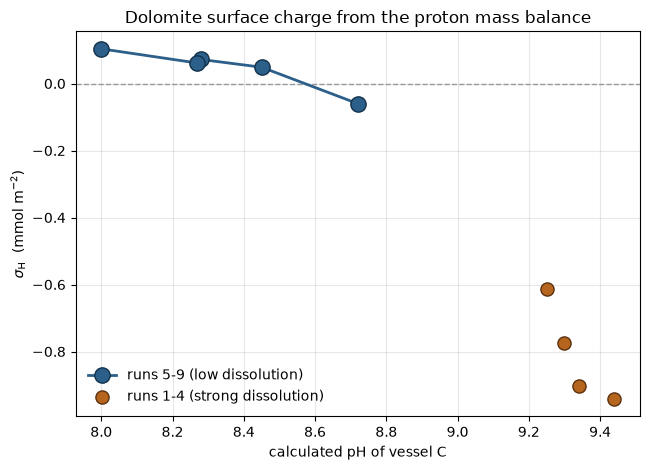

In [12]:
fig, ax = plt.subplots(figsize=(6.6, 4.8))
ax.axhline(0, color='0.6', lw=1.0, ls='--')

low  = surf[surf.index >= 5]     # little dissolution -> clean surface titration
high = surf[surf.index <= 4]     # strong dissolution

ax.plot(low['pH_calc (C)'], low['sigma_H (mmol/m2)'], '-o',
        color='#2c5f8a', mec='#12314a', ms=11, lw=2, label='runs 5-9 (low dissolution)')
ax.scatter(high['pH_calc (C)'], high['sigma_H (mmol/m2)'],
           color='#b5651d', ec='#5a3210', s=90, zorder=3, label='runs 1-4 (strong dissolution)')

ax.set_xlabel('calculated pH of vessel C')
ax.set_ylabel(r'$\sigma_\mathrm{H}$  (mmol m$^{-2}$)')
ax.set_title('Dolomite surface charge from the proton mass balance')
ax.legend(frameon=False)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('surface_charge_vs_pH.png', dpi=150)
plt.show()

## Notes

1. **No surface complexation model.** The surface charge is a proton mass balance between the
   conservative A+B mixture and the reacted suspension C — no site densities and no surface
   equilibrium constants are used.
2. **Open system.** CO₂(aq) is fixed by pCO₂, so the carbonate speciation follows from pCO₂ and pH.
   The fixed-CO₂ term cancels in the surface-charge difference.
3. **Calculated pH.** Every pH is obtained from the reactive-ion charge balance; the electrode
   reading is shown only for comparison. Forcing an open system *and* a calculated pH detaches the
   model pH from the experiment (e.g. large dissolved Ca/Mg in equilibrium with atmospheric CO₂ must
   be alkaline), so the calculated pH is an internal reference, not a prediction of the electrode.
4. **Activity coefficients = 1.** At the high ionic strength of these NaCl solutions a Davies / SIT /
   Pitzer correction would shift the numbers; add gamma factors inside `all_species` if needed.
5. **Charge coefficients.** NaCO₃⁻ carries −1 (not −2) and NaHCO₃(aq) is neutral; both were corrected
   in `sigma`.